# HW05: Word Embeddings

Remember that these homework work as a completion grade. **You can <span style="color:red">not</span> skip one section this homework.**

**Training word2vec**

In this section, we train a word2vec model using gensim. We train the model on text8 (which consists of the first 90M characters of a Wikipedia dump from 2006 and is considered one of the benchmarks for evaluating language models).

In [1]:
import gensim.downloader as api

api.info("text8")

{'num_records': 1701,
 'record_format': 'list of str (tokens)',
 'file_size': 33182058,
 'reader_code': 'https://github.com/RaRe-Technologies/gensim-data/releases/download/text8/__init__.py',
 'license': 'not found',
 'description': 'First 100,000,000 bytes of plain text from Wikipedia. Used for testing purposes; see wiki-english-* for proper full Wikipedia datasets.',
 'checksum': '68799af40b6bda07dfa47a32612e5364',
 'file_name': 'text8.gz',
 'read_more': ['http://mattmahoney.net/dc/textdata.html'],
 'parts': 1}

In [2]:
dataset = api.load("text8")

[==================================================] 100.0% 31.6/31.6MB downloaded


In [3]:
from gensim.models import Word2Vec

##TODO train a word2vec model on this dataset which appear at least 10 times in the corpus
model = Word2Vec(
    sentences=dataset,
    vector_size=100,
    window=5,
    min_count=10,
    workers=4
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


**Word Similarities**

gensim models provide almost all the utility you might want to wish for to perform standard word similarity tasks. They are available in the .wv (wordvectors) attribute of the model, more details could be found [here](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [4]:
model.wv

##TODO find the closest words to king
model.wv.most_similar("king", topn=10)

[('queen', 0.7183682322502136),
 ('prince', 0.7167765498161316),
 ('throne', 0.6935873031616211),
 ('kings', 0.6808913350105286),
 ('vii', 0.6785435080528259),
 ('regent', 0.6717202663421631),
 ('aragon', 0.6677067875862122),
 ('emperor', 0.6644582152366638),
 ('constantine', 0.6571202874183655),
 ('sultan', 0.6547446250915527)]

King is to man as woman is to X

In [5]:
##TODO find the closest word for the vector "woman" + "king" - "man"
model.wv.most_similar(positive=["woman", "king"], negative=["man"], topn=5)

[('queen', 0.6819495558738708),
 ('throne', 0.6010620594024658),
 ('princess', 0.599583089351654),
 ('prince', 0.5876126289367676),
 ('son', 0.5875990390777588)]

**Evaluate Word Similarities** 

One common way to evaluate word2vec models are word analogy tasks. Let's check how good our model is on one of those. We consider the [WordSim353](https://gabrilovich.com/resources/data/wordsim353/wordsim353.html) benchmark, the task is to determine how similar two words are.

In [9]:
!curl -L -o ws353simrel.tar.gz https://github.com/CallMeJiaGu/WordSimilarityAnalogyData/raw/refs/heads/master/ws353simrel.tar.gz
!tar xf ws353simrel.tar.gz

path = "wordsim353_sim_rel/wordsim_similarity_goldstandard.txt"

def load_data(path):
    X, y = [], []
    with open(path) as f:
        for line in f:
            line = line.strip().split("\t")
            X.append((line[0], line[1])) # each entry in x contains two words, e.g. X[0] = (tiger, cat)
            y.append(float(line[-1])) # each entry in y is the annotation how similar two words are, e.g. Y[0] = 7.35
    return X, y

X, y = load_data(path)
print (X[:3], y[:3])

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  5460  100  5460    0     0  10042      0 --:--:-- --:--:-- --:--:-- 10042
[('tiger', 'cat'), ('tiger', 'tiger'), ('plane', 'car')] [7.35, 10.0, 5.77]


In [10]:
##TODO compute how similar the pairs in the WordSim353 are according to our model
# if a word is not present in our model, we assign similarity 0 for the respective text pair

import numpy as np

predictions = []

for w1, w2 in X:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
    else:
        sim = 0
    predictions.append(sim)

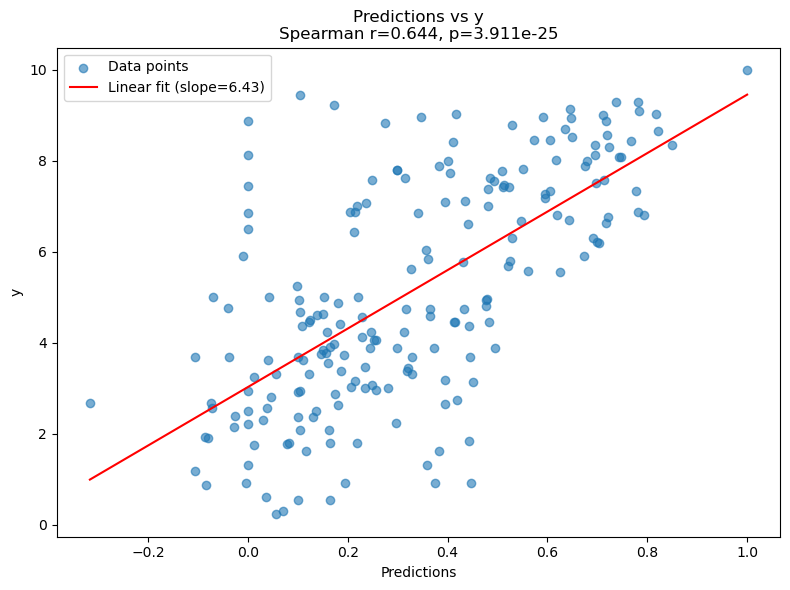

In [11]:
from scipy.stats import spearmanr

##TODO compute spearman's rank correlation between our prediction and the human annotations
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, linregress

# compute correlation
corr, p_value = spearmanr(predictions, y)

# linear fit
slope, intercept, r, p, se = linregress(predictions, y)
x_line = np.linspace(min(predictions), max(predictions), 100)
y_line = slope * x_line + intercept

# plot
plt.figure(figsize=(8, 6))
plt.scatter(predictions, y, alpha=0.6, label='Data points')
plt.plot(x_line, y_line, color='red', label=f'Linear fit (slope={slope:.2f})')
plt.xlabel('Predictions')
plt.ylabel('y')
plt.title(f'Predictions vs y\nSpearman r={corr:.3f}, p={p_value:.3e}')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/s0/qj_3vfv57l5bknx99kmph6sc0000gn/T/ipykernel_7332/3919426475.py:12: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Token.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  predictions.append(token1.similarity(token2))


Spearman correlation: 0.049215509939451944
p-value: 0.48561150533251957


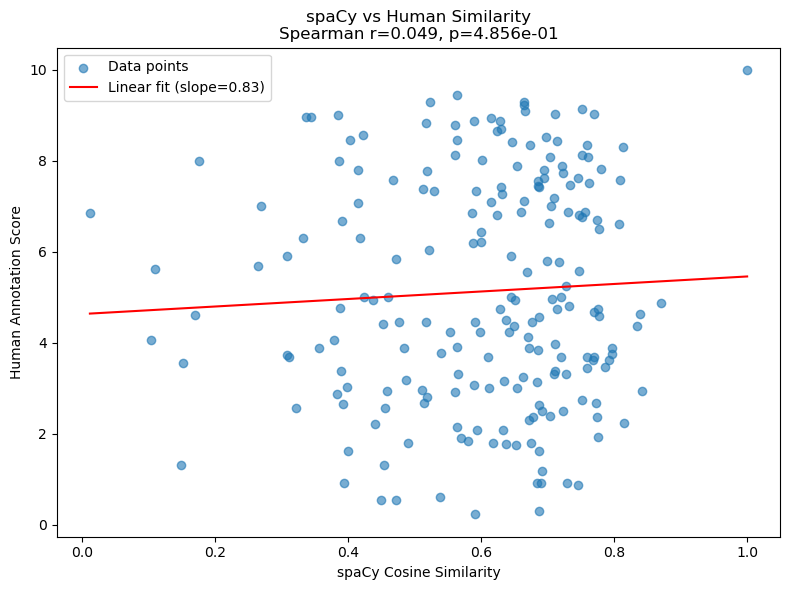

In [12]:
import spacy
en = spacy.load('en_core_web_sm')

##TODO compute word similarities in the WordSim353 dataset using spaCy word embeddings
##TODO compute spearman's rank correlation between these similarities and the human annotations
# Don't worry if results are not too convincing for this experiment

predictions = []
for word1, word2 in X:
    token1 = en(word1)[0]
    token2 = en(word2)[0]
    predictions.append(token1.similarity(token2))

corr, p_value = spearmanr(predictions, y)
print("Spearman correlation:", corr)
print("p-value:", p_value)

slope, intercept, *_ = linregress(predictions, y)
x_line = np.linspace(min(predictions), max(predictions), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 6))
plt.scatter(predictions, y, alpha=0.6, label='Data points')
plt.plot(x_line, y_line, color='red', label=f'Linear fit (slope={slope:.2f})')
plt.xlabel('spaCy Cosine Similarity')
plt.ylabel('Human Annotation Score')
plt.title(f'spaCy vs Human Similarity\nSpearman r={corr:.3f}, p={p_value:.3e}')
plt.legend()
plt.tight_layout()
plt.show()

**PyTorch Embeddings**

In [13]:
#Import the AG news dataset (same as hw01)
#Download them from here 
# !wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 
df["text"] = df["title"] + " " + df["lead"]
df = df.sample(n=10000) # # only use 10K datapoints
df.head()

,label,title,lead,text
39239,world,Web Posting Claims British Hostage Killed,"BAGHDAD, Iraq - An Internet posting claimed Sa...",Web Posting Claims British Hostage Killed BAGH...
86770,world,"Iraqi PM #39;s relatives kidnapped, face execu...",Two members of the Iraqi prime minister #39;s ...,"Iraqi PM #39;s relatives kidnapped, face execu..."
6930,sci/tech,The Call Is Cheap. The Wiretap Is Extra.,Wiretapping Internet phones to monitor crimina...,The Call Is Cheap. The Wiretap Is Extra. Wiret...
10522,world,"Two Bus Bombs in India Kill 4, Injure 39","GAUHATI, India Aug. 26, 2004 - A passenger bus...","Two Bus Bombs in India Kill 4, Injure 39 GAUHA..."
38228,sci/tech,Readers love mobiles in church; hate mobiles o...,&lt;strong&gt;Letters:&lt;/strong&gt; More fro...,Readers love mobiles in church; hate mobiles o...


In [15]:
import torch
import torch.nn as nn
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

vocab = 200
##TODO tokenize the text, only keep 200 most frequent words

X = df["text"].to_numpy()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize
train_tokens = [word_tokenize(sample.lower()) for sample in X_train]
test_tokens  = [word_tokenize(sample.lower()) for sample in X_test]

# Build vocabulary: <unk>=0, <pad>=1, then top 200 words
counter = Counter(token for sample in train_tokens for token in sample)
word2idx = {"<unk>": 0, "<pad>": 1}
for word, count in counter.most_common(vocab):
    if count >= 5:
        word2idx[word] = len(word2idx)

pad_index = torch.tensor(1)

def lookup(token):
    return word2idx.get(token, 0)

# Encode labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test  = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [17]:
length = 100
#TODO create a one_hot representation for each word and truncate/pad the sequences such that they are all of the same length (here we use 100)

def collate_fn(batch):
    sequences = [item[0] for item in batch]
    labels    = [item[1] for item in batch]
    sequences_padded = torch.nn.utils.rnn.pad_sequence(
        sequences, padding_value=pad_index, batch_first=True
    )
    return sequences_padded, torch.stack(labels)

train_dataset = [(torch.tensor([lookup(t) for t in tokens]), torch.tensor(label))
                 for tokens, label in zip(train_tokens, y_train)]
test_dataset  = [(torch.tensor([lookup(t) for t in tokens]), torch.tensor(label))
                 for tokens, label in zip(test_tokens, y_test)]

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [18]:
##TODO create your torch embedding like we did in notebook 5! (hint: predicting labels: world, sport, business, and sci/tech)

class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=1)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)    # [batch, seq_len, embed_dim]
        pooled   = embedded.mean(dim=1) # mean pooling → [batch, embed_dim]
        return self.fc(pooled)          # [batch, num_classes]

model_cls = EmbeddingClassifier(vocab_size=len(word2idx), embed_dim=64, num_classes=num_classes)

optimizer = torch.optim.Adam(model_cls.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def evaluate(loader):
    model_cls.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            preds = model_cls(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

for epoch in range(20):
    model_cls.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_cls(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_acc = evaluate(train_loader)
    test_acc  = evaluate(test_loader)
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.3f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

Epoch 1 | Loss: 1.369 | Train Acc: 0.388 | Test Acc: 0.356
Epoch 2 | Loss: 1.314 | Train Acc: 0.544 | Test Acc: 0.515
Epoch 3 | Loss: 1.228 | Train Acc: 0.594 | Test Acc: 0.560
Epoch 4 | Loss: 1.132 | Train Acc: 0.629 | Test Acc: 0.598
Epoch 5 | Loss: 1.041 | Train Acc: 0.653 | Test Acc: 0.620
Epoch 6 | Loss: 0.968 | Train Acc: 0.668 | Test Acc: 0.635
Epoch 7 | Loss: 0.912 | Train Acc: 0.680 | Test Acc: 0.653
Epoch 8 | Loss: 0.871 | Train Acc: 0.691 | Test Acc: 0.662
Epoch 9 | Loss: 0.835 | Train Acc: 0.697 | Test Acc: 0.671
Epoch 10 | Loss: 0.811 | Train Acc: 0.703 | Test Acc: 0.679
Epoch 11 | Loss: 0.791 | Train Acc: 0.706 | Test Acc: 0.689
Epoch 12 | Loss: 0.776 | Train Acc: 0.709 | Test Acc: 0.692
Epoch 13 | Loss: 0.764 | Train Acc: 0.715 | Test Acc: 0.696
Epoch 14 | Loss: 0.752 | Train Acc: 0.716 | Test Acc: 0.700
Epoch 15 | Loss: 0.744 | Train Acc: 0.722 | Test Acc: 0.701
Epoch 16 | Loss: 0.735 | Train Acc: 0.721 | Test Acc: 0.699
Epoch 17 | Loss: 0.730 | Train Acc: 0.726 | Test 